In [1]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

This script loads fluorescence intensity data for a specific replicate (`replicate_1`) and a background dataset. It defines helper functions to:
- Load and filter the data (`load_data`)
- Compute the average background intensity over frames 0–8 (`calculate_bg_intensity`)
- Compute the mean intensity at frame 0 (`calculate_mean_intensity`)
- Normalize the fluorescence signal per cell using background subtraction and normalization to frame 0 (`normalize_fluorescence`)

The normalized values are stored in a new column `fluo_norm` in the main dataframe.

In [ ]:
# File paths and parameters
file_path = '0_combined_df_pa_flush.csv'
file_path_background = '../../../Figure2/background/0_combined_df_bg.csv'
replicate = 'replicate_1'

# Function definitions
def load_data(file_path, file_path_background):
    df = pd.read_csv(file_path)
    df = df[df['replicate'] == replicate]
    df_bg = pd.read_csv(file_path_background)
    return df, df_bg

def calculate_bg_intensity(df_bg, frame_range):
    return df_bg[df_bg['frame_number'].isin(frame_range)]['intensity_raw_mcherry'].mean()

def calculate_mean_intensity(df, frame_number):
    return df[df['frame_number'] == frame_number]['intensity_raw_mcherry'].mean()

def normalize_fluorescence(df, bg_intensity, mean_intensity_frame_1):
    df['fluo_norm'] = (df['intensity_raw_mcherry'] - bg_intensity) / (mean_intensity_frame_1 - bg_intensity)

# Main flow
df, df_bg = load_data(file_path, file_path_background)
bg_intensity = calculate_bg_intensity(df_bg, range(0, 9))
mean_intensity_frame_1 = calculate_mean_intensity(df, 0)
normalize_fluorescence(df, bg_intensity, mean_intensity_frame_1)

This script computes a **threshold for fluorescent intensity** using KDE-based valley detection:

- **Input**: Fluorescence values at a specific frame (```frame_number == 100```).
- **KDE analysis**:
  - Computes the KDE curve over intensity values.
  - Finds the **first valley** (local minimum).
  - Identifies the **highest peak to the left** of that valley.
- **Threshold**: Calculated as the **midpoint between the left peak and the valley**.
- **Output**: Histogram, KDE curve, and threshold line plotted; threshold value printed.

This method separates low and high intensity populations in a **bimodal distribution**.



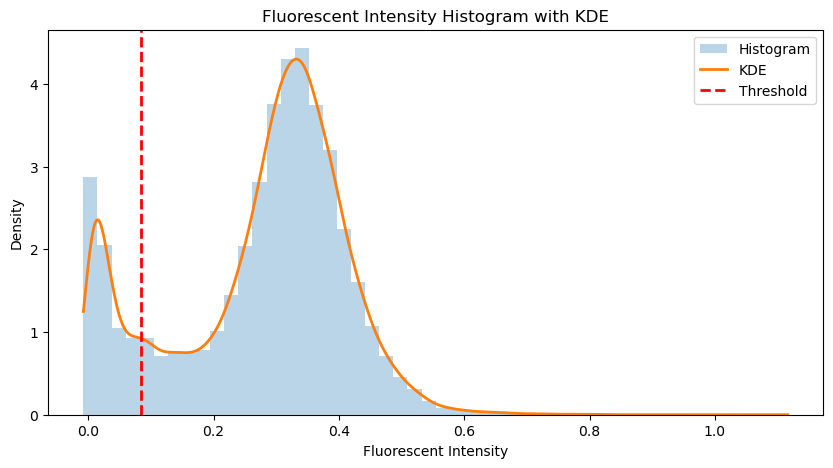

Threshold value: 0.08451844304264025


In [3]:
# Define the frame used for thresholding and visualization
threshold_frame = 100

plt.figure(figsize=(10, 5))

# Filter data for the specified frame
frame = df[df['frame_number'] == threshold_frame]
fluo_norm_values = frame['fluo_norm'].dropna().values

threshold = np.nan  # Default if no threshold found

if len(fluo_norm_values) > 0:
    kde = gaussian_kde(fluo_norm_values)
    x_range = np.linspace(min(fluo_norm_values), max(fluo_norm_values), 1000)
    kde_values = kde(x_range)

    # Find valleys (minima) in the KDE
    valleys, _ = find_peaks(-kde_values)

    if len(valleys) > 0:
        valley_idx = valleys[0]
        valley_x = x_range[valley_idx]

        # Find peaks (local maxima) in the KDE
        peaks, _ = find_peaks(kde_values)

        # Find the highest peak to the left of the valley
        left_peaks = [p for p in peaks if p < valley_idx]
        if left_peaks:
            left_peak_idx = max(left_peaks, key=lambda i: kde_values[i])
            left_peak_x = x_range[left_peak_idx]
            threshold = (left_peak_x + valley_x) / 2
        else:
            threshold = valley_x  # fallback if no left peak found

    # Plot
    plt.hist(fluo_norm_values, bins=50, alpha=0.3, density=True, label='Histogram')
    plt.plot(x_range, kde_values, linewidth=2, label='KDE')
    plt.axvline(threshold, color='r', linestyle='dashed', linewidth=2, label='Threshold')

plt.title('Fluorescent Intensity Histogram with KDE')
plt.xlabel('Fluorescent Intensity')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"Threshold value: {threshold}")


This block applies a **precomputed fluorescence threshold** to classify cells:

- Uses the existing ```threshold``` value (from KDE analysis).
- Assigns ```'r'``` if ```fluo_norm > threshold```, else ```'b'```.
- Saves the updated DataFrame (```fluo_binary``` column) to CSV.

In [ ]:
# --- Classification function ---
def classify_fluorescence(df, threshold):
    df['fluo_binary'] = np.where(df['fluo_norm'] > threshold, 'r', 'b')
    return df

# --- Use precomputed threshold ---
# Assumes `threshold` was defined earlier using KDE logic
df = classify_fluorescence(df, threshold)

# --- Save output ---
output_path = '1_fluo_binary_pa_flush.csv'
df.to_csv(output_path, index=False)